In [1]:
import pandas as pd
df = pd.read_excel('fast_food_30000_dataset.xlsx')
df['Price'] = df['Price'].replace('[₹,]','',regex=True).astype(float)
df.dropna()

,Brand,Item,Price,Category,Calories,Protein,Fat,Carbs,City,State,Month,Rating
0,McDonalds,Double Chocolate Frappe,227.0,Other,477,33,24,30,Hyderabad,Telangana,February,4.0
1,McDonalds,Coke Regular,71.0,Beverage,473,22,12,38,Chennai,Tamil Nadu,September,3.8
2,McDonalds,Mcspicy Chicken Burger,159.0,Chicken,635,22,17,54,Chandigarh,Punjab,March,4.3
3,McDonalds,Fanta Large,88.0,Other,212,31,36,65,Gurgaon,Haryana,April,4.4
4,McDonalds,Mcspicy Paneer Burger,159.0,Burger,380,16,18,72,Gurgaon,Haryana,July,3.6
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,Burger King,Chicken Kings Meal Combo For 4,745.0,Chicken,654,16,23,36,Ahmedabad,Gujarat,June,4.5
29996,KFC,2 Pc Hot & Crispy Chicken,200.0,Chicken,407,9,25,47,Noida,Uttar Pradesh,June,4.4
29997,McDonalds,Chicken Mcnuggets 6 Pcs Meal Large,274.0,Chicken,263,7,6,77,Indore,Madhya Pradesh,August,3.8
29998,KFC,Ultimate Savings Bucket,599.0,Other,208,14,35,23,Mumbai,Maharashtra,June,3.5


In [2]:
df['Calories_per_rupees'] = df['Calories'] / df['Price']
df['Protein_per_rupees'] = df['Protein'] / df['Price']
df['Health_score'] = (df['Protein']*2) - (df['Carbs'] + df['Fat'])
df

,Brand,Item,Price,Category,Calories,Protein,Fat,Carbs,City,State,Month,Rating,Calories_per_rupees,Protein_per_rupees,Health_score
0,McDonalds,Double Chocolate Frappe,227.0,Other,477,33,24,30,Hyderabad,Telangana,February,4.0,2.101322,0.145374,12
1,McDonalds,Coke Regular,71.0,Beverage,473,22,12,38,Chennai,Tamil Nadu,September,3.8,6.661972,0.309859,-6
2,McDonalds,Mcspicy Chicken Burger,159.0,Chicken,635,22,17,54,Chandigarh,Punjab,March,4.3,3.993711,0.138365,-27
3,McDonalds,Fanta Large,88.0,Other,212,31,36,65,Gurgaon,Haryana,April,4.4,2.409091,0.352273,-39
4,McDonalds,Mcspicy Paneer Burger,159.0,Burger,380,16,18,72,Gurgaon,Haryana,July,3.6,2.389937,0.100629,-58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,Burger King,Chicken Kings Meal Combo For 4,745.0,Chicken,654,16,23,36,Ahmedabad,Gujarat,June,4.5,0.877852,0.021477,-27
29996,KFC,2 Pc Hot & Crispy Chicken,200.0,Chicken,407,9,25,47,Noida,Uttar Pradesh,June,4.4,2.035000,0.045000,-54
29997,McDonalds,Chicken Mcnuggets 6 Pcs Meal Large,274.0,Chicken,263,7,6,77,Indore,Madhya Pradesh,August,3.8,0.959854,0.025547,-69
29998,KFC,Ultimate Savings Bucket,599.0,Other,208,14,35,23,Mumbai,Maharashtra,June,3.5,0.347245,0.023372,-30


In [3]:
category_stats = df.groupby('Category').agg({
    'Price':'mean',
    'Calories':'mean',
    'Rating':'mean'
}).reset_index()
brand_stats = df.groupby('Brand').agg({
    'Price':'mean',
    'Rating':'mean'
}).reset_index()
month_stats = df.groupby('Month').agg({
    'Price':'mean',
    'Rating':'mean'
}).reset_index()

In [4]:
df.groupby('Category')['Rating'].mean()
df.groupby('Brand')['Price'].mean()
df.describe()

,Price,Calories,Protein,Fat,Carbs,Rating,Calories_per_rupees,Protein_per_rupees,Health_score
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,248.607033,448.902633,20.032033,22.506533,49.982833,4.146560,3.127246,0.139180,-32.425300
std,181.249975,144.295190,8.936178,10.385032,17.552713,0.376603,3.166989,0.151703,27.206177
min,22.000000,200.000000,5.000000,5.000000,20.000000,3.500000,0.221249,0.005476,-109.000000
25%,128.000000,324.000000,12.000000,13.000000,35.000000,3.800000,1.259019,0.048696,-52.000000
50%,199.000000,448.000000,20.000000,22.000000,50.000000,4.100000,2.148674,0.093548,-32.000000
75%,306.000000,575.000000,28.000000,32.000000,65.000000,4.500000,3.778808,0.169014,-13.000000
max,913.000000,700.000000,35.000000,40.000000,80.000000,4.800000,31.727273,1.590909,44.000000


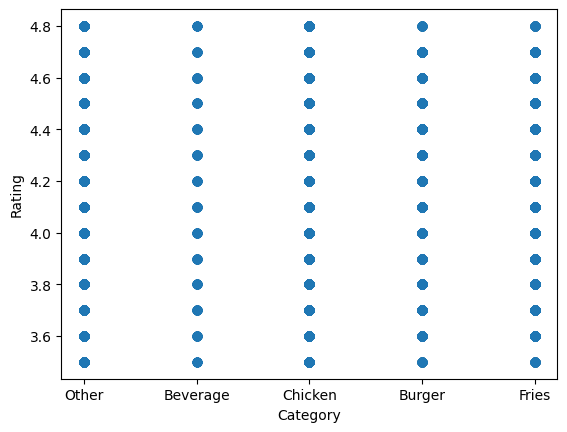

In [5]:
import matplotlib.pyplot as plt
plt.scatter(df['Category'],df['Rating'])
plt.xlabel('Category')
plt.ylabel('Rating')
plt.show()

In [7]:
df.to_csv('fastfood_dashboard_dataset.csv',index=False)
category_stats.to_csv('category_stats.csv',index=False)
brand_stats.to_csv('brand_stats.csv',index=False)
month_stats.to_csv('month_stats.csv',index=False)
